In [2]:
import pandas as pd

# Plot the accuracy 

df = pd.read_csv(
    './data/results/errors__operators[1,10,88]_runs[40]_wKNN[K=2,RF=NSINR]_clustering[N=0-10,RF=NSINR].csv')

df


,0,1,2,3,4,5,6,7,8,9,10
0,16.128535,16.128535,16.181947,16.204070,16.015528,16.128606,16.213698,16.432030,16.438743,16.167225,16.062597
1,12.943326,12.943326,12.943326,13.106758,12.834907,12.913479,13.128615,13.249263,13.050028,13.001506,13.293527
2,14.142183,14.142183,14.122870,14.164217,14.152836,14.522187,14.222303,14.401707,14.099829,13.970663,14.239036
3,15.167541,15.167541,15.167541,15.060762,15.246014,15.439294,15.497980,15.140564,15.277442,15.305293,15.396863
4,15.365097,15.365097,15.365097,15.473655,15.622598,15.486412,15.253476,15.608840,16.032573,15.888614,15.428760
5,15.425615,15.425615,15.483058,15.446830,15.452486,15.563608,15.598389,15.585772,15.754450,15.612155,15.676360
6,14.826082,14.826082,14.877107,14.912748,14.792660,15.132592,15.137656,14.834251,15.064520,15.164008,15.527610
7,13.215978,13.215978,13.215978,13.177128,13.492383,13.363469,13.320351,13.564161,13.627569,13.568590,13.234189
8,13.285594,13.285594,13.302847,13.228839,13.278660,13.339106,13.393343,13.668502,13.702512,13.540888,13.701220
9,15.577662,15.577662,15.440426,15.519416,15.698136,15.859815,15.850243,16.030032,15.829345,15.638603,15.849746


In [3]:
df_2 = df.copy()

df_2

df_3 = df.copy()

df['frequency'] = 800

df_2['frequency'] = 2400

df_3['frequency'] = 'both'

merged = pd.concat([df, df_2, df_3], axis=0, ignore_index=True)



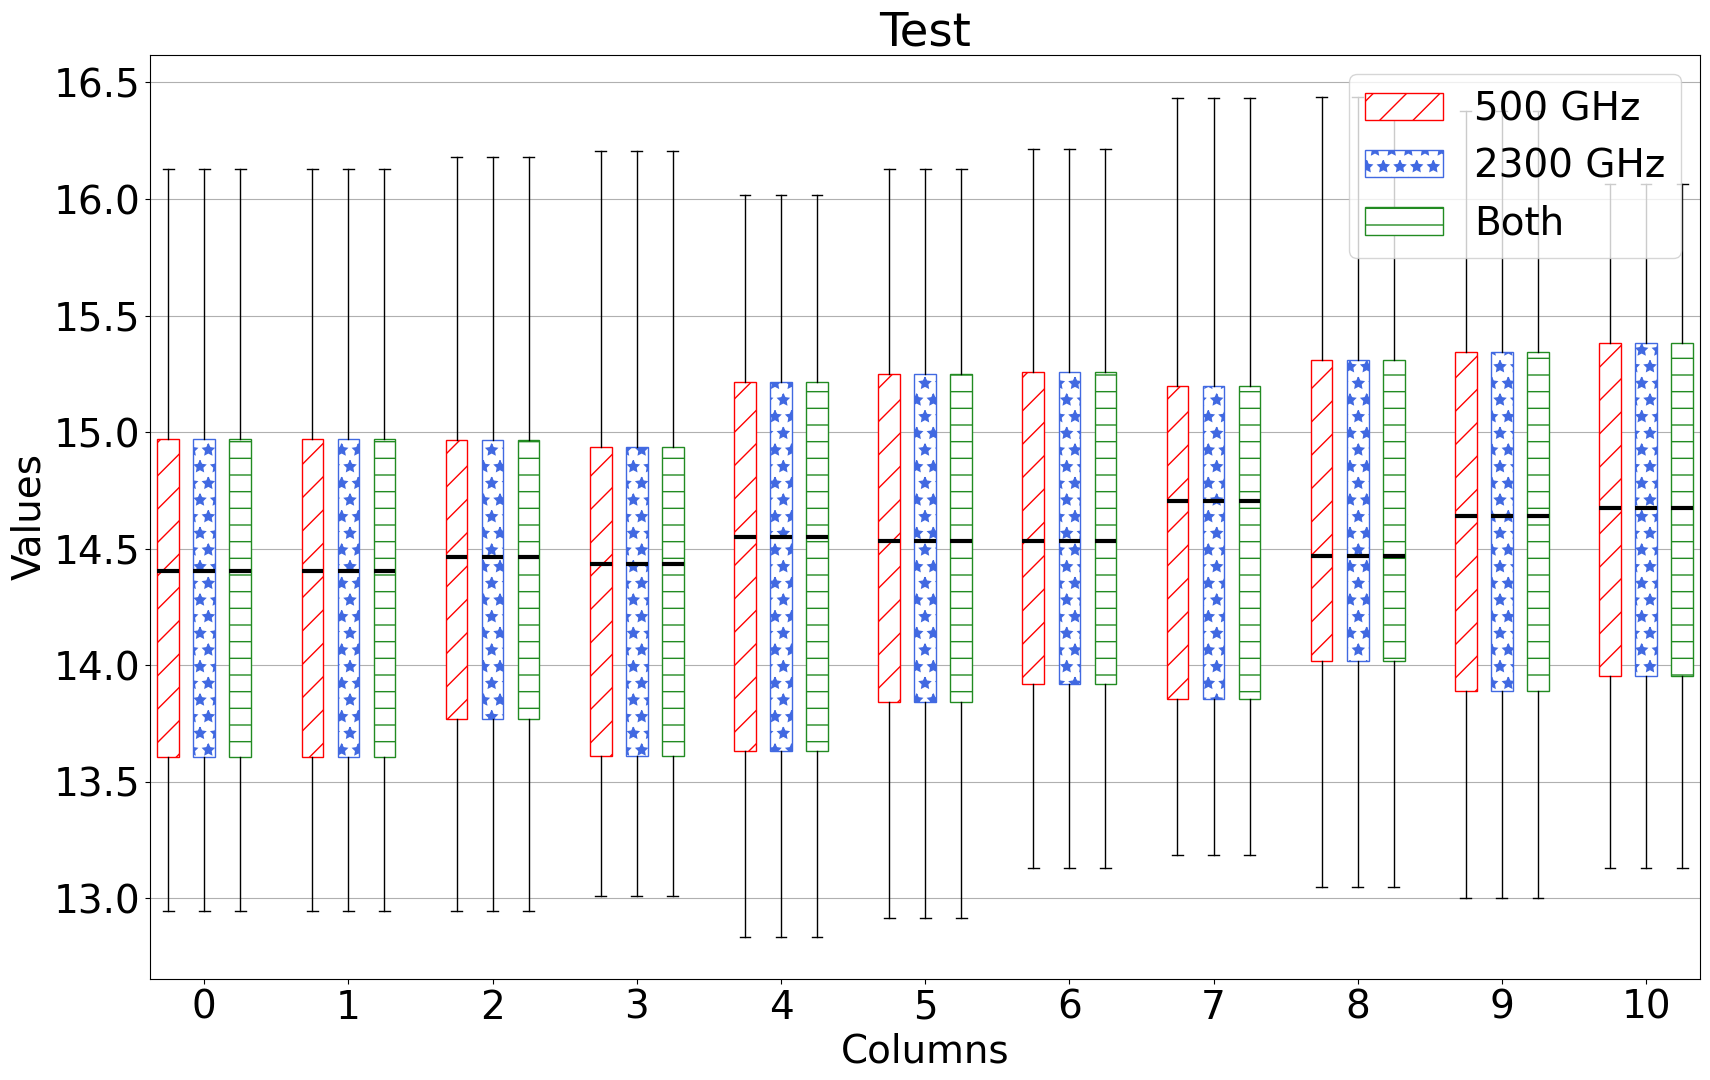

In [4]:
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 28})


def make_boxplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        baseline: float = None,
        group_by: dict = None
):
    """
    Creates a boxplot of the given dataframe with optional grouping.

    :param df: DataFrame containing the data to plot
    :param title: Title of the plot
    :param x_label: Label for the x-axis
    :param y_label: Label for the y-axis
    :param baseline: Optional baseline to draw on the plot
    :param group_by: Dictionary containing group information
    """
    if group_by and group_by['by'] in df.columns:
        group_column = group_by['by']
        colors = group_by.get('colors', ['forestgreen', 'royalblue'])
        hatches = group_by.get('hatches', ['/', '.'])
        labels = group_by.get('labels', [''])
        unique_frequencies = df[group_column].unique()
        num_columns = len(df.columns) - 1
        data_values = []
        positions = []

        for i, column in enumerate(df.columns):
            if column != group_column:
                for j, freq in enumerate(unique_frequencies):
                    group_data = df[df[group_column] == freq]
                    data_values.append(group_data[column].values)
                    positions.append(i * (len(unique_frequencies) + 1) + j)

        plt.figure(figsize=(20, 12))
        median_props = dict(color="black", linewidth="3")
        plot = plt.boxplot(
            data_values,
            patch_artist=True,
            positions=positions,
            widths=0.6,
            medianprops=median_props,
        )
        for i, patch in enumerate(plot["boxes"]):
            color = colors[i % len(colors)]
            hatch = hatches[i % len(hatches)]
            patch.set_facecolor('white')
            patch.set_edgecolor(color)
            patch.set_hatch(hatch)

        if baseline:
            plt.axhline(
                y=baseline,
                color="red",
                linestyle="-",
                linewidth=2,
                label="Baseline",
            )
            plt.legend(loc="upper right")

        # Formatting the plot
        plt.title(title)
        plt.grid(axis="y")
        plt.xlabel(x_label)
        plt.ylabel(y_label)

        # Set x-ticks
        plt.xticks(
            ticks=[i * (len(unique_frequencies) + 1) + (len(unique_frequencies) - 1) / 2 for i in range(num_columns)],
            labels=df.columns.drop(group_column)
        )

        # Add a legend
        handles = [Patch(edgecolor=color, facecolor='white', hatch=hatch,
                         label=f"{label}")
                   for color, hatch, freq, label in zip(colors, hatches, unique_frequencies, labels)]
        plt.legend(handles=handles, loc="upper right")

        # Show the plot
        plt.show()


group_data = {
    'by': 'frequency',
    'unit': 'GHz',
    'label': 'Frequency',
    'labels': ['500 GHz', '2300 GHz', 'Both'],
    'colors': ['red', 'royalblue', 'forestgreen'],
    'hatches': ['/', '*', '-']
}

make_boxplot(
    merged,
    title="Test",
    x_label="Columns",
    y_label="Values",
    group_by=group_data
)
